In [1]:

import torch
from torch import nn
from torch.nn import functional as F


import wandb
import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from torch.utils.data import DataLoader
from xaikd.utils import metrics
from xaikd import models, datasets

from contextlib import nullcontext

from datetime import datetime

from matplotlib import colormaps

from xaikd.models.vgg import canonize_model


from zennit.attribution import Gradient
from zennit.composites import EpsilonGammaBox, EpsilonPlusFlat
from xaikd import datasets, models, utils

from torchvision import transforms


from collections import OrderedDict

In [2]:
api = wandb.Api()

In [3]:
PROJECT = "p16i/xaikd-distillation-layerwise-s21"
EXPERIMENT_GROUP = "./artifacts/2024-02-s21/experiments/1-imagenet-butterfly"

In [4]:
def read_data(
    teacher,
    student,
    dataset,
    policy,
    lambda_task,
    lambda_kd,
    training_size,
    contamination_level,    
    verbose=False,
    return_raw = False
):
    
    
    runs = api.runs(
        PROJECT,
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            {"config.dataset": dataset},
            {"config.training_size": training_size},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    datasets = []
    for run in runs:
        seed = run.config["seed"]
        
        if not "arr_metrics"in run.summary:
            print(">> bad run config")
            print(run.config)
            count += 1
            return run
            continue
                                 
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        datasets.append(run.config["dataset"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]


        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                # remark: this is the actual value used in distillation
                # cf. https://github.com/p16i/xai-kd/blob/2023-09-s14--1-teacher-training-script/scripts/distill-layerwise.py#L364
                lambda_layer=run.config["policy_lambda_layer"],
                val_acc=best_val_acc, 
                teacher_acc=run.summary["teacher_acc"],
                policy=run.config["policy"],
                run_id=run.id
            )
        )

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
    df = df.sort_values(by=["lambda_layer", "seed"], ascending=True)
        
        
    if return_raw:
        return df
        
    df = df.groupby(by="lambda_layer").agg(
        {
            "val_acc": ["mean", "std", "count"],
            "teacher_acc": ["mean"],
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        3
    )
    
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="imagenet-vgg16-tv",
    dataset="imagenet-butterfly-spurious0.5",
    student="vggcustomimagenetdims-32-24-24-10",
    lambda_task=0.0,
    lambda_kd=1.0,
    policy="basis-identity:pca--uncentered",
    training_size=0.125,
    verbose=True,
    contamination_level=0.0,
)

summary

we have 12 runs
df.shape: (4, 5)


lambda_layer   val_acc                 teacher_acc
                    mean       std count        mean
0            1  0.685556  0.013878     3    0.956667
1           10  0.832222  0.020367     3    0.956667
2          100  0.853333  0.021858     3    0.956667
3         1000  0.845556  0.025459     3    0.956667

In [5]:
summary = read_data(
    teacher="imagenet-vgg16-tv",
    dataset="imagenet-butterfly-spurious0.5",
    student="vggcustomimagenetdims-32-24-24-10",
    lambda_task=0.0,
    lambda_kd=1.0,
    policy="basis-identity:pca--uncentered",
    training_size=0.125,
    verbose=True,
    contamination_level=0.0,
    return_raw=True
)

summary

we have 12 runs


,best_epoch,seed,lambda_task,lambda_kd,lambda_layer,val_acc,teacher_acc,policy,run_id
11,96,1,0,1,1,0.690000,0.956667,basis-identity:pca--uncentered,r6qkwcar
10,87,2,0,1,1,0.670000,0.956667,basis-identity:pca--uncentered,i3fpec2j
9,87,3,0,1,1,0.696667,0.956667,basis-identity:pca--uncentered,07rwfc7g
8,96,1,0,1,10,0.836667,0.956667,basis-identity:pca--uncentered,9sqwo7qv
7,92,2,0,1,10,0.850000,0.956667,basis-identity:pca--uncentered,5kk8sj77
6,99,3,0,1,10,0.810000,0.956667,basis-identity:pca--uncentered,35i7u0rz
5,86,1,0,1,100,0.856667,0.956667,basis-identity:pca--uncentered,she92qpu
4,69,2,0,1,100,0.830000,0.956667,basis-identity:pca--uncentered,09o5y6ms
3,75,3,0,1,100,0.873333,0.956667,basis-identity:pca--uncentered,mo3rm3t5
2,82,1,0,1,1000,0.840000,0.956667,basis-identity:pca--uncentered,h5nciail


In [6]:
def alias(name):
        __dd = {
            "basis-identity:random--uncentered": "Random Directions",
            "basis-identity:pca--uncentered": "PCA (Ours)",
            "basis-identity:prca-sortabs--uncentered": "PRCA-sortabs (Ours)",
            "vid": "VID",
            "nothing": "KD Only"

        }
        return __dd.get(name, name)
    
def color(name):
        __dd = {
            "basis-identity:random--uncentered": "lightgray"
        }
        return __dd.get(name, None)

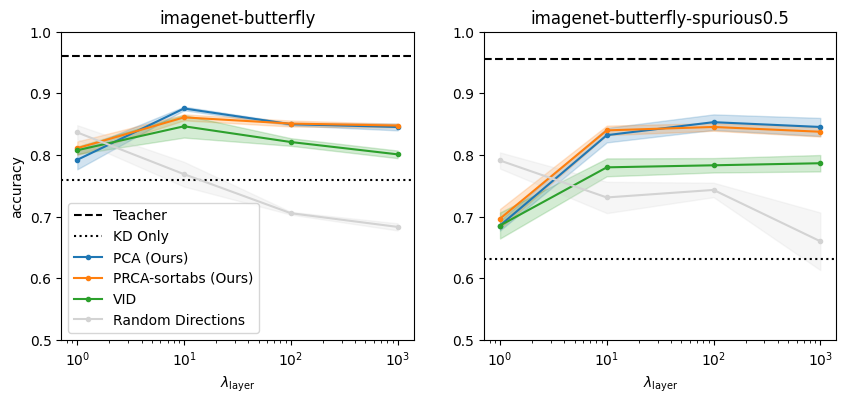

In [7]:
def viz():

    arr_datasets = [
        "imagenet-butterfly",
        "imagenet-butterfly-spurious0.5"
    ]
    
    lambda_task = 0.0
    lambda_kd = 1.0
    
    teacher = "imagenet-vgg16-tv"
    student = "vggcustomimagenetdims-32-24-24-10"
    
    arr_policies = [
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "vid",
        "basis-identity:random--uncentered"
    ]
    
    trainining_size = 0.125
    
    ncols = len(arr_datasets)
    
    plt.figure(figsize=(5*ncols, 4))
    
    for dix, dataset in enumerate(arr_datasets):
        plt.subplot(1, ncols, dix+1)
        
        plt.title(dataset)
        
        for pix, policy in enumerate(arr_policies):
            df = read_data(
                teacher=teacher,
                dataset=dataset,
                student=student,
                lambda_task=lambda_task,
                lambda_kd=lambda_kd,
                policy=policy,
                training_size=trainining_size,
                contamination_level=0.0,
            )
            
            if pix == 0:
                teacher_acc = df["teacher_acc"].values[0] 
                plt.axhline(teacher_acc, ls="--", label="Teacher", color="k")
                plt.ylim([0.5, 1])
            
            
                df_kdonly = read_data(
                    teacher=teacher,
                    dataset=dataset,
                    student=student,
                    lambda_task=lambda_task,
                    lambda_kd=lambda_kd,
                    policy="nothing",
                    training_size=trainining_size,
                    contamination_level=0.0,
                )
                
                kdonly_acc = df_kdonly["val_acc"]["mean"].values[0]
                plt.axhline(kdonly_acc, ls=":", label="KD Only", color="k")

            arr_lambdas = df["lambda_layer"].values
            count = df["val_acc"]["count"].values[0]
            
            mean = df["val_acc"]["mean"].values
            stderr = df["val_acc"]["std"] / (count ** 0.5)
            
            plt.plot(
                arr_lambdas, mean, 
                label=alias(policy),
                color=color(policy),
                marker="."
            )
            plt.fill_between(
                arr_lambdas, 
                mean - stderr,
                mean + stderr, 
                alpha=0.2,
                color=plt.gca().lines[-1].get_color()
            )
            
     
        
        if dix == 0:
            plt.legend()
        
            plt.ylabel("accuracy")
        
        plt.xscale("log")
        plt.xlabel(r"$\lambda_{\mathrm{layer}}$")
viz()

plt.savefig('./figures-tac3/imagenet-butterfly/distillation-accuracy-lambda-layers.pdf')

# Viz Heatmaps

In [8]:
ds = datasets.construct("imagenet-butterfly")

ds_val = ds.create_subset(train_split=False)
ds_val.transform = lambda x: x

We have 300 images in classes [321, 322, 323, 324, 325, 326]


preparing `ImageNetButterfly` samples: 100%|█████████████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 2717691.58it/s]


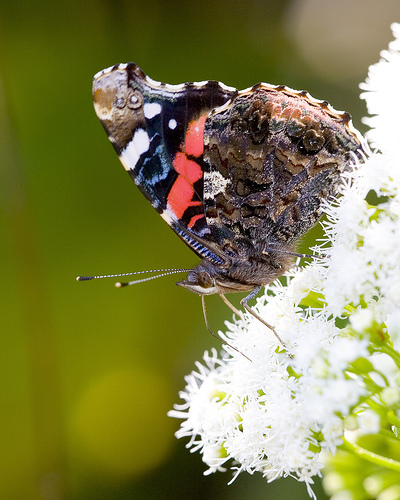

In [9]:
image, label = ds_val[2]
image

In [10]:
ds.selected_classes

[321, 322, 323, 324, 325, 326]

In [11]:
teacher_label, student_label = ds.selected_classes[label], label

teacher_label, student_label

(321, 0)

In [12]:
teacher_model = models.get_trained_model("imagenet-vgg16-tv")

In [13]:
input_transform = ds.input_transformation

input_transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [14]:
rc_transform = transforms.Compose(
    [transforms.Resize(256), transforms.CenterCrop(224)]
)

In [15]:
from torchvision.datasets.folder import default_loader

copyright = default_loader("../../resources/copyright/1.png")

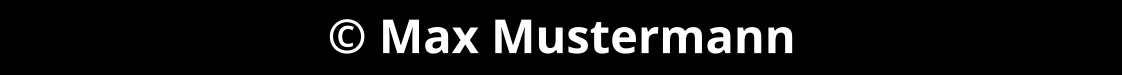

In [16]:
copyright

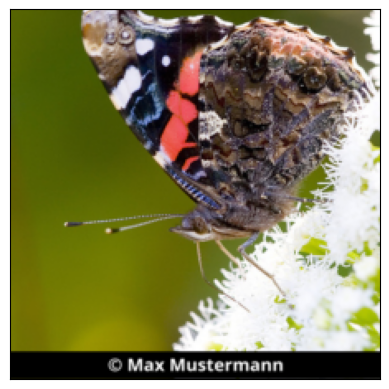

In [17]:
plt.imshow(
    rc_transform(utils.apply_copyright_to_image(image, copyright))
); plt.xticks([]); plt.yticks([])

plt.savefig('./figures-tac3/imagenet-butterfly/spurious.jpg', dpi=150)

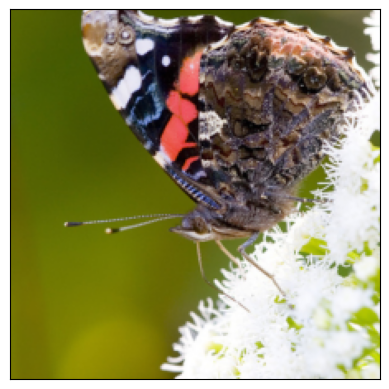

In [18]:
plt.imshow(
    rc_transform(image)
); plt.xticks([]); plt.yticks([])


plt.savefig('./figures-tac3/imagenet-butterfly/clean.jpg', dpi=150)

In [19]:
from matplotlib.colors import ListedColormap
import numpy as np

def _heatmap(
    heatmap,
    title="",
    logit=None,
    reference_heatmap=None,
    total_score=None,
    fontsize="small",
    xlabel_prefix=""
):
    """Plot heatmap; this is adapted from https://git.tu-berlin.de/gmontavon/lrp-tutorial/-/blob/main/utils.py

    Args:
        heatmap np.array(h, w):
        reference_heatmap (np.array(h, w), optional): used for calculating normalization values. Defaults to None.
        total_score (float, optional): used for normalizing scores. Defaults to None.
    """
    assert len(heatmap.shape) == 2

    if reference_heatmap is None:
        reference_heatmap = heatmap

    assert len(reference_heatmap.shape) == 2

    b = np.abs(reference_heatmap).max()

    my_cmap = plt.cm.seismic(np.arange(plt.cm.seismic.N))
    my_cmap[:, 0:3] *= 0.85
    my_cmap = ListedColormap(my_cmap)

    sum_Ri = np.sum(heatmap)
    if total_score is None:
        percent = 100
        txt = r"%s $\sum_i R_i=%.2f$" % (xlabel_prefix, sum_Ri)
    else:
        percent = (sum_Ri / total_score) * 100
        txt = r"%s $\sum_i R_i=%.4f$ (%3.1f%%)" % (xlabel_prefix, sum_Ri, percent)

    plt.axis("on")
    plt.xticks([])
    plt.yticks([])
    plt.imshow(heatmap, cmap=my_cmap, vmin=-b, vmax=b)

    h = heatmap.shape[0]
    
    plt.title(f"{title}", fontsize=fontsize)
    if logit is not None:
        plt.xlabel(f"{txt}, logit={logit:.4f}", fontsize=fontsize)
    else:
        plt.xlabel(f"{txt}", fontsize=fontsize)
        

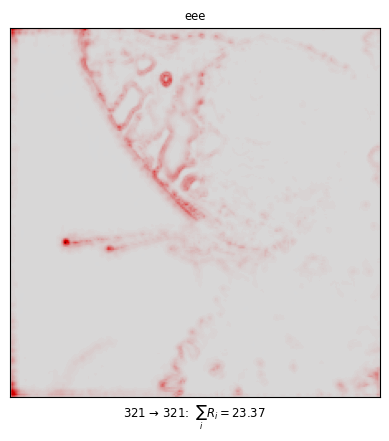

In [20]:
def get_attributor_for_model(model):
    
    normalizer = transforms.Normalize(
        mean=input_transform.mean,
        std=input_transform.std
    )
    
    low, high = normalizer(torch.tensor([[[[[0.0]]] * 3], [[[[1.0]]] * 3]]))

    composite = EpsilonGammaBox(low=low, high=high, canonizers=[])

    return Gradient(model=model, composite=composite)


def viz_heatmap(
    model, 
    img, 
    label, 
    num_classes,
    title="",
):
        
    data = input_transform(img)[None]
    
    logit_mod = lambda logits: logits * F.one_hot(torch.Tensor([label]).long(), num_classes)

    # create the attributor, specifying model
    with get_attributor_for_model(model) as attributor:
        # compute the model output and attribution
        output, attribution = attributor(data, logit_mod)
    
    heatmap = attribution.numpy().sum(axis=1).squeeze()
    output = output.detach().numpy().squeeze()
    ypred = np.argmax(output)
    
    _heatmap(
        heatmap, title=title, 
        xlabel_prefix=f"{label} → {ypred}: "
    )


viz_heatmap(teacher_model, image, teacher_label, num_classes=1000, title="eee")

In [21]:
wandapi = wandb.Api()

In [22]:

def load_trained_student_model(student, runid, num_classes=6):
    
    
    run =  wandapi.run(f"{PROJECT}/{runid}")
    policy = run.config["policy"]

    artifact = wandapi.artifact(f"{PROJECT}/model-{runid}:best")

    artifact_dir = artifact.download()
    
    ckpt = torch.load(f"{artifact_dir}/model.ckpt", map_location=torch.device('cpu'))
    
    state_dict = ckpt["state_dict"]
    
    student_state_dict = dict()
    for key in state_dict.keys():
        if key.split(".")[0] == "student":
            student_state_dict[key] = state_dict[key]
            
    
        
    student = models.get_untrained_model(student, num_classes=num_classes)

    trainer_wrapper = nn.Sequential(OrderedDict([("student", student)]))
    trainer_wrapper.load_state_dict(student_state_dict)


    return student

def load_model_and_canonize(student, runid):
    
    trained_model = load_trained_student_model(student, runid)
    
    canonized_model = canonize_model(trained_model)
    canonized_model.eval()
    
    return canonized_model

def get_distill_model(
    dataset, 
    teacher, 
    student, 
    policy,
    lambda_layer,
    lambda_task=0.0,
    lambda_kd=1.0,
    training_size=0.125,
):
    
    
    df = read_data(
        teacher=teacher, 
        dataset=dataset,
        student=student,
        lambda_task=lambda_task,
        lambda_kd=lambda_kd,
        policy=policy,
        training_size=training_size,
        verbose=True,
        contamination_level=0.0,
        return_raw=True
    )
    
    
    df = df[(df.seed == 1) & (df.lambda_layer == lambda_layer)]

    run_id = df["run_id"].values[0]
    
    model = load_model_and_canonize(student, run_id)
    
    return model

get_distill_model(
    dataset="imagenet-butterfly", 
    teacher="imagenet-vgg16-tv",
    student="vggcustomimagenetdims-32-24-24-10",
    policy="vid",
    lambda_layer=1.0
)

we have 12 runs


wandb:   1 of 1 files downloaded.  


Sequential(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(32, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU()
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (17): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding

we have 3 runs


wandb:   1 of 1 files downloaded.  


we have 12 runs


wandb:   1 of 1 files downloaded.  


we have 12 runs


...

wandb:   1 of 1 files downloaded.  


we have 12 runs


wandb:   1 of 1 files downloaded.  


we have 12 runs


wandb:   1 of 1 files downloaded.  


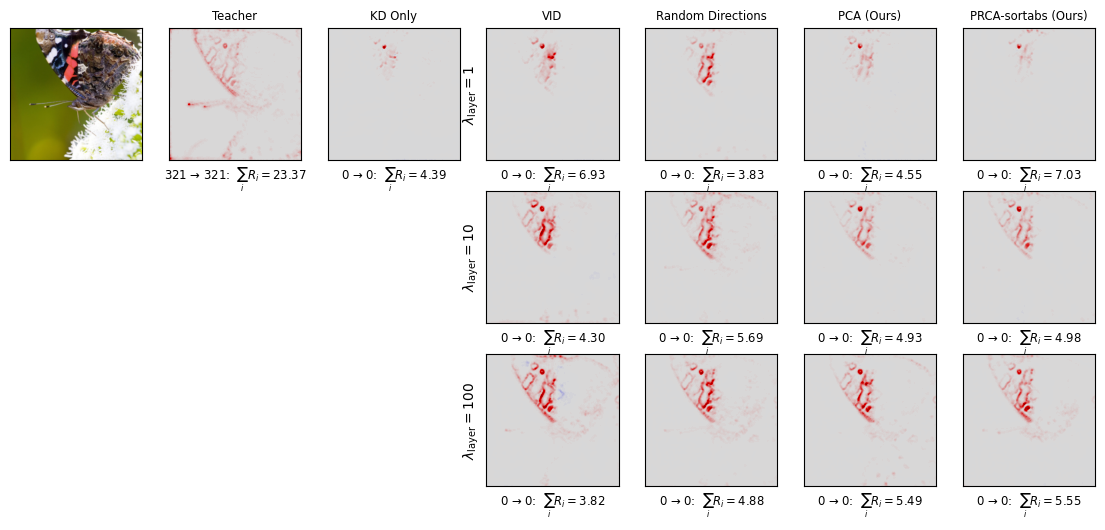

In [26]:
def viz_heatmap_comparison(
    image,
    dataset,
):
    
    assert dataset in ["imagenet-butterfly-spurious0.5", "imagenet-butterfly"]
    if dataset == "imagenet-butterfly-spurious0.5":
        image = utils.apply_copyright_to_image(image, copyright)
    
    arr_policies = [
        "vid",
        "basis-identity:random--uncentered",
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
    ]
    
    arr_lambdas = [
        1,
        10,
        100
    ]
    
    teacher = "imagenet-vgg16-tv"
    student = "vggcustomimagenetdims-32-24-24-10"
    student_num_classes = len(ds.selected_classes)

    nrows = len(arr_lambdas)
    ncols = 3 + len(arr_policies)
    
    plt.figure(figsize=(2*ncols, 2*nrows))
    
    plt.subplot(nrows, ncols, 1)
    
    plt.imshow(rc_transform(image)); plt.xticks([]); plt.yticks([])
    
    plt.subplot(nrows, ncols, 2)
    plt.title("Teacher")
    viz_heatmap(
        teacher_model, image, teacher_label, 
        num_classes=1000, title="Teacher"
    )
    
    plt.subplot(nrows, ncols, 3)
    viz_heatmap(
         get_distill_model(
            dataset=dataset, 
            teacher=teacher,
            student=student,
            policy="nothing",
            lambda_layer=0
        ), 
        image, student_label,
        num_classes=student_num_classes,
        title=alias("nothing")
    )
    
    for lix, lambda_layer in enumerate(arr_lambdas):
        for pix, policy in enumerate(arr_policies):
            plt.subplot(nrows, ncols, ncols*lix + 4 + pix)
            
            distilled_model =  get_distill_model(
                dataset=dataset, 
                teacher=teacher,
                student=student,
                policy=policy,
                lambda_layer=lambda_layer
            )

            viz_heatmap(
                distilled_model, image, student_label,
                num_classes=student_num_classes,
                title=alias(policy) if lix == 0 else ""
            )

            if pix == 0:
                plt.ylabel("$\lambda_\mathrm{layer}=%d$" % int(lambda_layer))
                
viz_heatmap_comparison(
    image=image,
    dataset="imagenet-butterfly"
)

we have 3 runs


wandb:   1 of 1 files downloaded.  


we have 12 runs


wandb:   1 of 1 files downloaded.  


we have 12 runs


...

wandb:   1 of 1 files downloaded.  


we have 12 runs


wandb:   1 of 1 files downloaded.  


we have 12 runs


wandb:   1 of 1 files downloaded.  


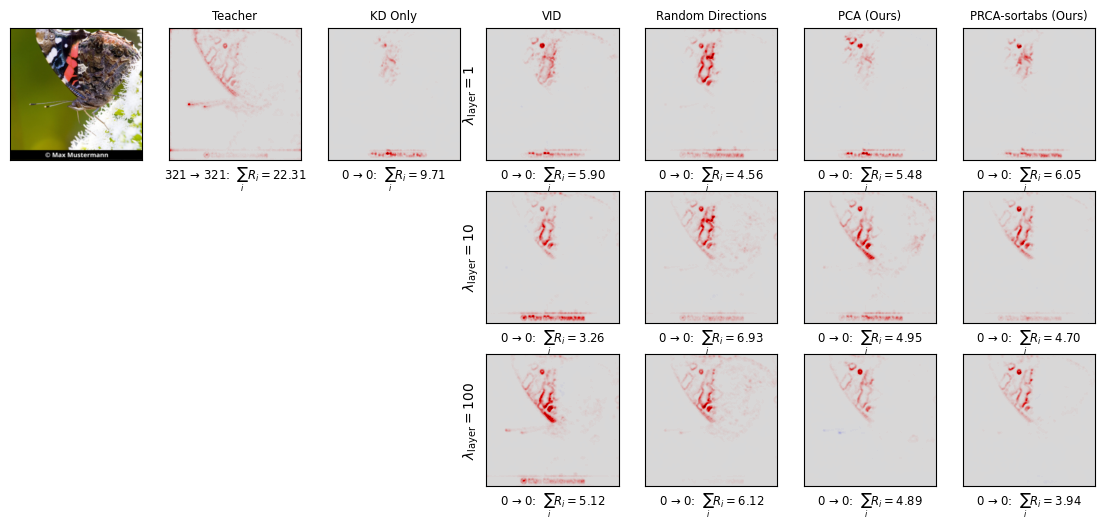

In [28]:
viz_heatmap_comparison(
    image=image,
    dataset="imagenet-butterfly-spurious0.5"
)
plt.savefig('./figures-tac3/imagenet-butterfly/heatmaps-raw.png', dpi=150)